In [1]:
%pip install statsmodels

# https://github.com/marcopeix/TimeSeriesForecastingInPython/tree/master/CH03

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
df = pd.read_csv('./data/GOOGL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


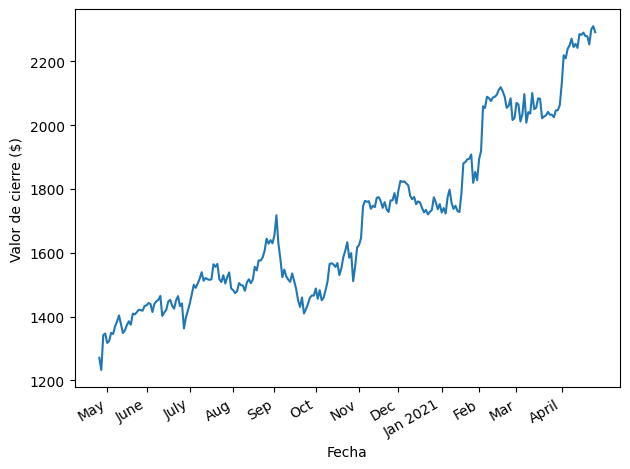

In [4]:
fig, ax = plt.subplots()

ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor de cierre ($)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

## Proceso Random Walk

The numpy library allows us to generate numbers from a normal distribution by using the standard_normal method. This ensures that the numbers come from a distribution with mean of 0, as per the definition of white noise; I’ve also given it a variance of 1 (a normal distribution). Then we can set the very first value of our series to 0. Finally, the cumsum method will calculate the cumulative sum of white noise for each timestep in our series, and we will have simulated our random walk

In [5]:
np.random.seed(42)

steps = np.random.standard_normal(1000)
steps[0]=0

random_walk = np.cumsum(steps)

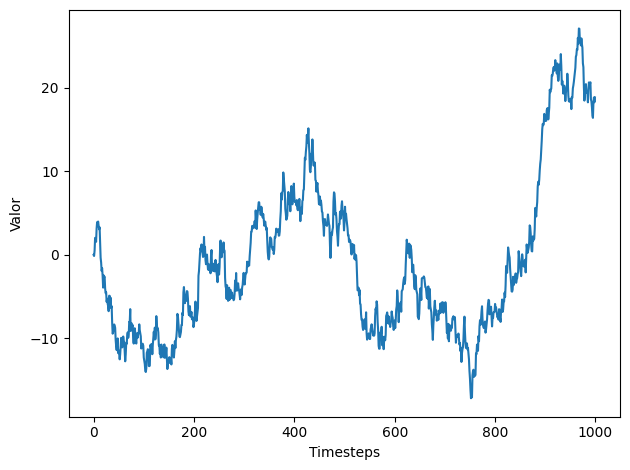

In [6]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Valor')

plt.tight_layout()
plt.savefig('images/CH03_F03.png', dpi=300)

## Comprobando la estacionalidad


A stationary time series is one whose statistical properties do not change over time

In [7]:
def simulate_process(is_stationary: bool) -> np.array:
    np.random.seed(42)
    process = np.empty(400)
    
    if is_stationary:
        alpha = 0.5
        process[0] = 0
    else:
        alpha = 1
        process[0] = 10
        
    for i in range(400):
        if i+1 < 400:
            process[i+1] = alpha*process[i] + np.random.standard_normal()
        else:
            break
        
    return process

In [8]:
stationary = simulate_process(True)
non_stationary = simulate_process(False)

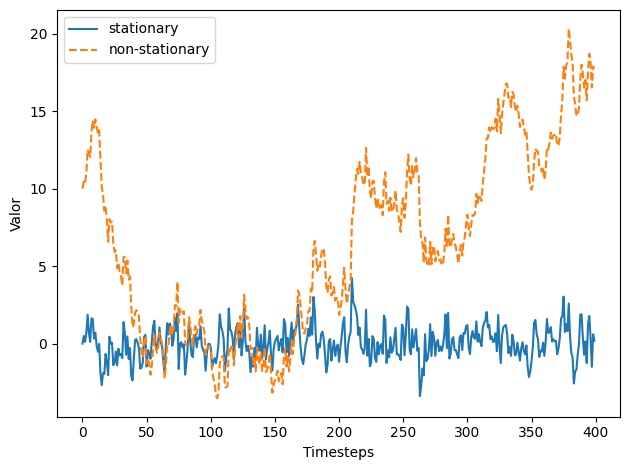

In [9]:
fig, ax = plt.subplots()

ax.plot(stationary, linestyle='-', label='stationary')
ax.plot(non_stationary, linestyle='--', label='non-stationary')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Valor')
ax.legend(loc=2)

plt.tight_layout()
plt.savefig('images/CH03_F06.png', dpi=300)

The autocorrelation function (ACF) measures the linear relationship between lagged values of a time series.

In the presence of a trend, a plot of the ACF will show that the coefficients are high for short lags, and they will decrease linearly as the lag increases. If the data is seasonal, the ACF plot will also display cyclical patterns.

In [10]:
from statsmodels.tsa.stattools import adfuller
 
ADF_result = adfuller(random_walk)
 
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')


ADF Statistic: -0.9659524876918755
p-value: 0.7654789696692579


The ADF statistic is not a large negative number, and with a p-value greater than 0.05, we cannot reject the null hypothesis stating that our time series is not stationary. 

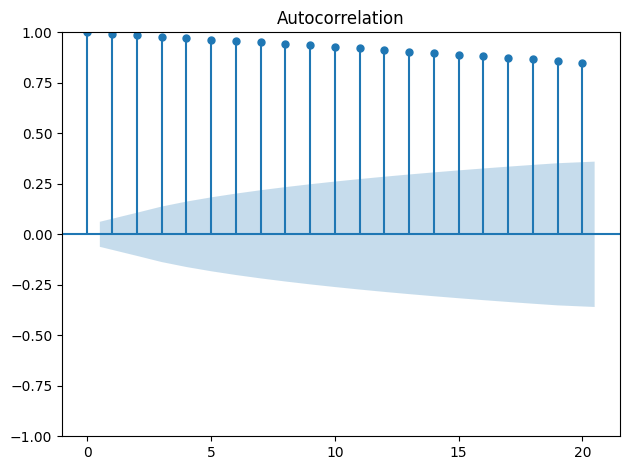

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
 
plot_acf(random_walk, lags=20);

plt.tight_layout()
plt.savefig('images/CH03_F09.png', dpi=300)

In [12]:
diff_random_walk = np.diff(random_walk, n=1)

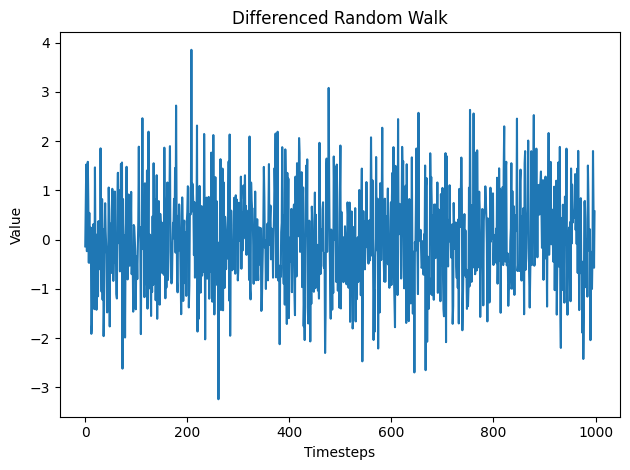

In [13]:
plt.plot(diff_random_walk)
plt.title('Differenced Random Walk')
plt.xlabel('Timesteps')
plt.ylabel('Value')
plt.tight_layout()

plt.savefig('images/CH03_F10.png', dpi=300)

In [14]:
ADF_result = adfuller(diff_random_walk)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -31.789310857560594
p-value: 0.0


This time the ADF statistic is a large negative number, and the p-value is less than 0.05

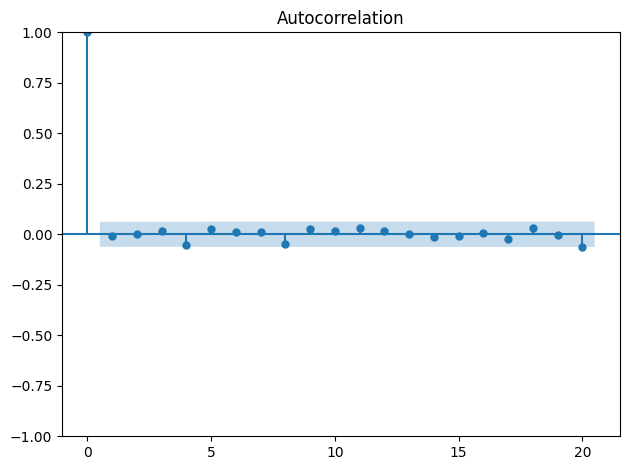

In [15]:

plot_acf(diff_random_walk, lags=20);

plt.tight_layout()

plt.savefig('images/CH03_F11.png', dpi=300)

there are no significant autocorrelation coefficients after lag 0. This means that the stationary process is completely random and can therefore be described as white noise. Each value is simply a random step away from the previous one, with no relation between them

## GOOGL Random Walk?

In [16]:
df = pd.read_csv('data/GOOGL.csv')

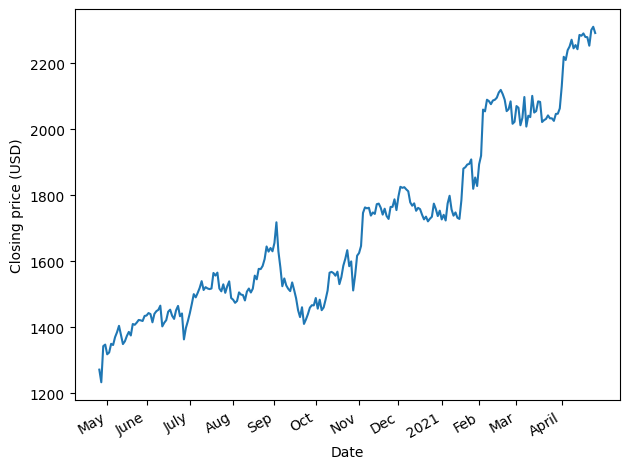

In [17]:
fig, ax = plt.subplots()
 
ax.plot(df['Date'], df['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')
 
plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 2021, 'Feb', 'Mar', 'April'])
 
fig.autofmt_xdate()
plt.tight_layout()

In [18]:
GOOGL_ADF_result = adfuller(df['Close'])

print(f'ADF Statistic: {GOOGL_ADF_result[0]}')
print(f'p-value: {GOOGL_ADF_result[1]}')

ADF Statistic: 0.16025048664771283
p-value: 0.9699419435913057


ADF statistic of 0.16 and a p-value greater than 0.05, so we know that our data is not stationary

In [19]:
diff_close = np.diff(df['Close'], n=1)

In [20]:
GOOGL_diff_ADF_result = adfuller(diff_close)

print(f'ADF Statistic: {GOOGL_diff_ADF_result[0]}')
print(f'p-value: {GOOGL_diff_ADF_result[1]}')

ADF Statistic: -5.303439704295231
p-value: 5.386530961454658e-06


This gives an ADF statistic of –5.3 and a p-value smaller than 0.05, meaning that we have a stationary process.

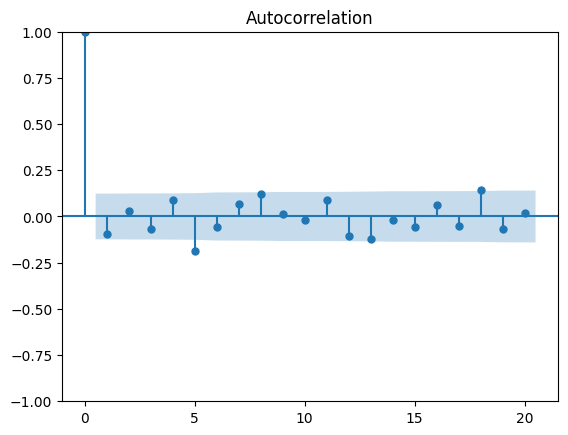

In [21]:
plot_acf(diff_close, lags=20);

plt.savefig('images/CH03_F13.png', dpi=300)

## Forecasting a random walk

In [22]:
df = pd.DataFrame({'value': random_walk})

train = df[:800]
test = df[800:]

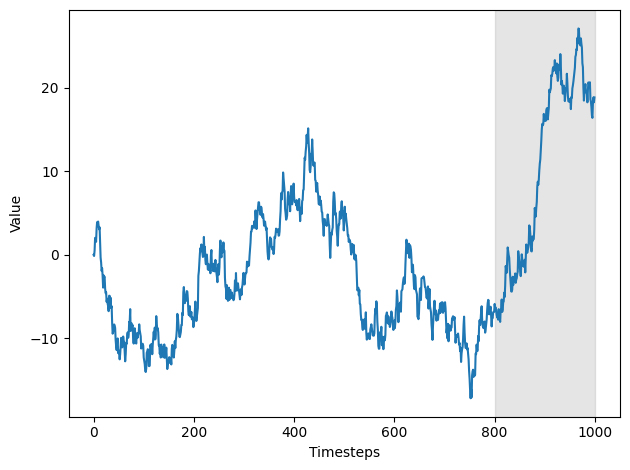

In [23]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(800, 1000, color='#808080', alpha=0.2)

plt.tight_layout()
plt.savefig('images/CH03_F14.png', dpi=300)

In [24]:
mean = np.mean(train.value)

test.loc[:, 'pred_mean'] = mean

test.head()

,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


In [25]:
last_value = train.iloc[-1].value

test.loc[:, 'pred_last'] = last_value

test.head()

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


 The **drift** method is a modification of predicting the last known value. In this case, we allow the values to increase or decrease over time. The rate at which values will change in the future is equal to that seen in the train set. Therefore, it is equivalent to calculating the slope (*pendiente*) between the first and last value of the train set and simply extrapolating this straight line into the future.

In [26]:
deltaX = 800 - 1
deltaY = last_value - 0

drift = deltaY / deltaX

x_vals = np.arange(801, 1001, 1)

pred_drift = drift * x_vals

test.loc[:, 'pred_drift'] = pred_drift

test.head()

,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.832006
801,-6.392708,-3.677206,-6.814947,-6.840536
802,-6.296588,-3.677206,-6.814947,-6.849065
803,-6.758863,-3.677206,-6.814947,-6.857594
804,-7.193359,-3.677206,-6.814947,-6.866124


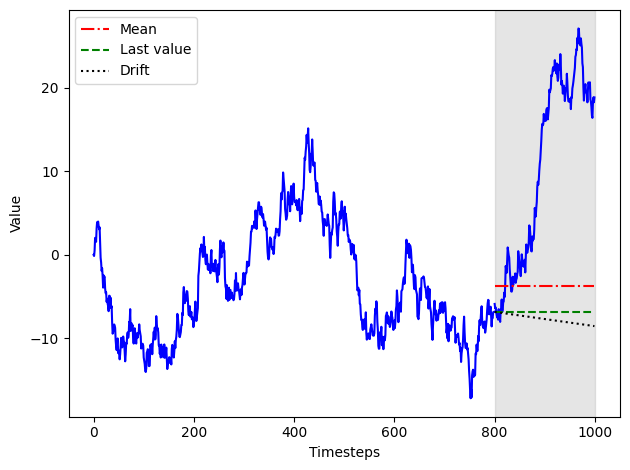

In [27]:
fig, ax = plt.subplots()

ax.plot(train.value, 'b-')
ax.plot(test['value'], 'b-')
ax.plot(test['pred_mean'], 'r-.', label='Mean')
ax.plot(test['pred_last'], 'g--', label='Last value')
ax.plot(test['pred_drift'], 'k:', label='Drift')

ax.axvspan(800, 1000, color='#808080', alpha=0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('images/CH03_F15.png', dpi=300)

In [28]:
from sklearn.metrics import mean_squared_error
 
mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last'])
mse_drift = mean_squared_error(test['value'], test['pred_drift'])
 
print(mse_mean, mse_last, mse_drift)

326.50277395297474 425.1726033055617 466.2172769077409


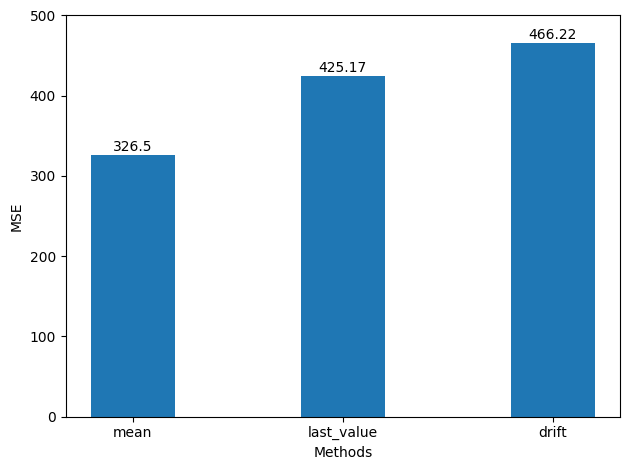

In [29]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'drift']
y = [mse_mean, mse_last, mse_drift]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 500)

for index, value in enumerate(y):
    plt.text(x=index, y=value+5, s=str(round(value, 2)), ha='center')

plt.tight_layout()

plt.savefig('images/CH03_F16.png', dpi=300)

In [30]:
df_shift = df.shift(periods=1)
 
df_shift.head()


,value
0,NaN
1,0.000000
2,-0.138264
3,0.509424
4,2.032454


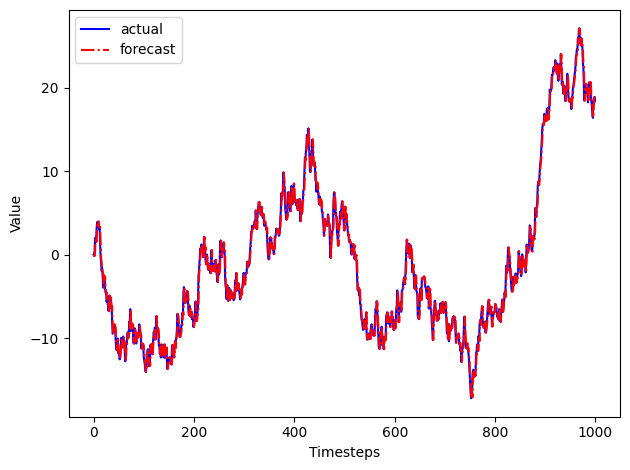

In [31]:
fig, ax = plt.subplots()
 
ax.plot(df, 'b-', label='actual')
ax.plot(df_shift, 'r-.', label='forecast')
 
ax.legend(loc=2)
 
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
 
plt.tight_layout()

In [32]:
mse_one_step = mean_squared_error(test['value'], df_shift[800:])
 
print(mse_one_step)


0.9256876651440581


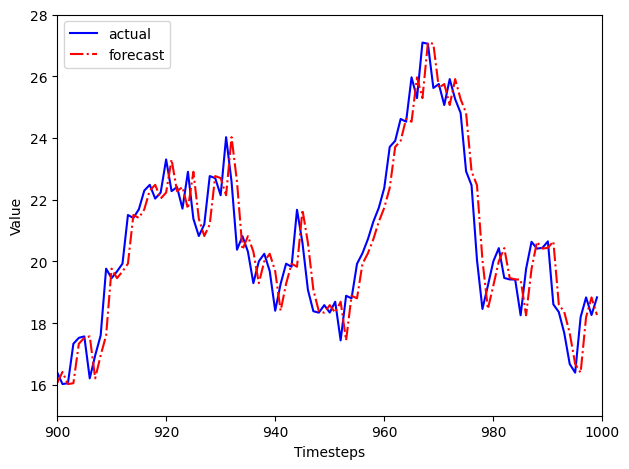

In [33]:
fig, ax = plt.subplots()

ax.plot(df, 'b-', label='actual')
ax.plot(df_shift, 'r-.', label='forecast')

ax.legend(loc=2)

ax.set_xlim(900, 1000)
ax.set_ylim(15, 28)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

plt.savefig('images/CH03_F19.png', dpi=300)

 if a random walk process must be forecast, it is better to make many short-term forecasts. That way, we do not allow for many random numbers to accumulate over time, which will degrade the quality of our forecasts in the long term.